In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *

In [3]:
# initialize spark
spark = SparkSession.builder \
    .appName("News Data Analysis") \
    .config("spark.driver.extraJavaOptions", "-Xlog:disable") \
    .config("spark.executor.extraJavaOptions", "-Xlog:disable") \
    .getOrCreate()

# define the schema
schema = StructType([
    StructField("timestamp", IntegerType(), True),
    StructField("source", StringType(), True),
    StructField("archive", StringType(), True),
    StructField("id", IntegerType(), True),
    StructField("probability", FloatType(), True),
    StructField("keywords", MapType(StringType(), IntegerType()), True),
    StructField("sentiment", FloatType(), True),
    #StructField("status", StringType(), True),
    #StructField("error", StringType(), True)
])

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/03/13 23:51:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


**global data analysis**

In [4]:
df = spark.read.format("json").schema(schema).load("data/news/status=success")
df02 = spark.read.format("json").schema(schema).load("data/news/status=error")
df03 = spark.read.format("json").schema(schema).load("data/news/status=duplicate")
df04 = spark.read.format("json").schema(schema).load("data/news/status=notnews")

print("Total number of links taken into consideration: ", df.count() + df02.count() + df03.count() + df04.count())
print("Number of actually news: ", df.count())
print(f"which are distributed across {len(df.inputFiles())} files.")

OpenJDK 64-Bit Server VM warning: CodeCache is full. Compiler has been disabled.
OpenJDK 64-Bit Server VM warning: Try increasing the code cache size using -XX:ReservedCodeCacheSize=


CodeCache: size=131072Kb used=25147Kb max_used=25164Kb free=105924Kb
 bounds [0x000000010818c000, 0x0000000109a4c000, 0x000000011018c000]
 total_blobs=10328 nmethods=9404 adapters=836
 compilation: disabled (not enough contiguous free space left)
Total number of links taken into consideration:  1561700


Number of actually news:  318578
which are distributed across 2858 files.


In [5]:
df.printSchema()

root
 |-- timestamp: integer (nullable = true)
 |-- source: string (nullable = true)
 |-- archive: string (nullable = true)
 |-- id: integer (nullable = true)
 |-- probability: float (nullable = true)
 |-- keywords: map (nullable = true)
 |    |-- key: string
 |    |-- value: integer (valueContainsNull = true)
 |-- sentiment: float (nullable = true)



In [6]:
df.show(5)

+---------+----------------+--------------------+------+-----------+--------------------+-----------+
|timestamp|          source|             archive|    id|probability|            keywords|  sentiment|
+---------+----------------+--------------------+------+-----------+--------------------+-----------+
|   201709|Correio da Manhã|https://arquivo.p...|701644| 0.58617663|{Amazon Carlos Ro...|  0.6422417|
|   201709|Correio da Manhã|https://arquivo.p...|700910|  0.5093835|{Finge -> 1, aero...| -0.5444501|
|   201709|Correio da Manhã|https://arquivo.p...|700927|    0.57878|{falha -> 2, Fing...|-0.56717324|
|   201709|Correio da Manhã|https://arquivo.p...|700218|  0.5356582|{Impresso -> 1, P...|-0.54087096|
|   201709|Correio da Manhã|https://arquivo.p...|700475|  0.5083431|{restrição -> 2, ...|-0.33665743|
+---------+----------------+--------------------+------+-----------+--------------------+-----------+
only showing top 5 rows



**filtering query**

benchmarking the performance of the query

with cache

```
Galp: 18.44
galp: 13.70
Millenium: 16.94
```

without cache

```
Millenium: > 31
```

In [7]:
query = "Galp"

In [8]:
from pyspark.sql import functions as F

query_col_counts = F.col("keywords").getItem(query)
df_with_query = df.filter(query_col_counts.isNotNull() & (query_col_counts > 4)).cache()

print(f"Number of news with the query: {df_with_query.count()}")

df_with_query.show(5)

Number of news with the query: 690
+---------+----------------+--------------------+------+-----------+--------------------+-----------+
|timestamp|          source|             archive|    id|probability|            keywords|  sentiment|
+---------+----------------+--------------------+------+-----------+--------------------+-----------+
|   201708|           AEIOU|https://arquivo.p...|686118| 0.59610814|{seleção -> 2, ca...|  0.6072352|
|   201708|Correio da Manhã|https://arquivo.p...|687291|  0.6604433|{seleção -> 4, di...| 0.60608214|
|   201708|           AEIOU|https://arquivo.p...|685645| 0.58374906|{Finlândia -> 1, ...|-0.59838146|
|   201802|   Dinheiro Vivo|https://arquivo.p...|856600|  0.7689971|{seguro -> 2, bre...|  0.6115333|
|   201802|Correio da Manhã|https://arquivo.p...|856462|   0.631486|{falha -> 16, Emp...| -0.5705586|
+---------+----------------+--------------------+------+-----------+--------------------+-----------+
only showing top 5 rows



In [9]:
# Process data
result = (
    df_with_query.rdd
    .flatMap(lambda row: [
        (key, (value,
               {row["timestamp"]: value},
               row["sentiment"]*value,
               {row["source"]: 1},
               [row["archive"]])) for key, value in row["keywords"].items()
    ])
    .reduceByKey(lambda a, b: (
        a[0] + b[0],  # Sum count values
        {ts: a[1].get(ts, 0) + b[1].get(ts, 0) for ts in set(a[1]) | set(b[1])},  # Merge timestamp counts
        a[2] + b[2],  # Sum sentiment values
        {source: a[3].get(source, 0) + b[3].get(source, 0) for source in set(a[3]) | set(b[3])},  # Merge source counts
        a[4] + b[4]  # Merge archive lists
    ))
    .collect()
)

# Convert to dictionary
output = {key: {"count": value[0],
                "date": value[1],
                "sentiment": value[2]/value[0],
                "source": value[3],
                "news": value[4]} for key, value in result}

print(f"The outputs is a {type(output)} with {len(output)} topics related to {query}.")
print(f"The keys are the topics and the values are dictionaries with the following keys: {list(output.values())[0].keys()}")

The outputs is a <class 'dict'> with 20336 topics related to Galp.
The keys are the topics and the values are dictionaries with the following keys: dict_keys(['count', 'date', 'sentiment', 'source', 'news'])


In [10]:
import json

file_path = 'data/keywords_test.json'

# Save the dictionary to a JSON file
#with open(file_path, 'w') as json_file:
#    json.dump(output, json_file, indent=4)

#print(f"JSON data saved to {file_path}")

# Load the JSON data back into a Python dictionary
#with open(file_path, 'r') as json_file:
#    loaded_data = json.load(json_file)

# Print loaded data
#print("Loaded data:")
#loaded_data

**creating the graph**

just use the graph.py file to create it

the variable output is the input for the graph.py file

**query info and statistics**

- number of news (add pie plot showing % ?)

In [11]:
print(f"Number of news with the query: {df_with_query.count()} out of {df.count()}, between {1900} and {2025}.")
print("Note: may replace in the future the df.count() with a fixed integer, avoiding computation.")

Number of news with the query: 690 out of 318578, between 1900 and 2025.
Note: may replace in the future the df.count() with a fixed integer, avoiding computation.


- source of news

In [29]:
from pyspark.sql import functions as F
import plotly.graph_objects as go

# Group by the column and count the values
value_counts_df = df_with_query.groupBy('source').count().toPandas()

# Extract labels and values directly
labels = value_counts_df['source']
values = value_counts_df['count']

fig = go.Figure(data=[go.Pie(labels=labels,
                             values=values)])

#fig.update_traces(textposition='inside')
#fig.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')
fig.update_traces(textposition='inside', textfont_size=12)

fig.show()

- number of news and top10 words by month

In [13]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import collect_list
import pandas as pd
import plotly.express as px

news_by_month = (
    df_with_query
    .groupBy('timestamp')
    .agg(F.count('archive').alias('count_of_news'))
    .toPandas()
)

keywords_by_month = (
    df_with_query
    .select('*', F.explode('keywords'))
    .groupBy("timestamp", "key")
    .agg(F.sum("value").alias("key_mentions"))
    .filter(F.col("key") != query)
    .withColumn("rank", F.row_number().over(Window.partitionBy("timestamp").orderBy(F.desc("key_mentions"))))
    .filter(F.col("rank") <= 5)
    .groupBy("timestamp")
    .agg(collect_list("key").alias("top5_keywords"))
    .toPandas()
)

news_history = news_by_month.merge(keywords_by_month, on="timestamp", how="inner")
news_history["timestamp"] = pd.to_datetime(news_history["timestamp"].astype(str), format='%Y%m')
news_history = news_history.sort_values(by="timestamp")

print(news_history.columns)

# Create Plotly figure
fig = px.line(
    news_history,
    x="timestamp",
    y="count_of_news",
    hover_data={"top5_keywords": True},  # Shows keyword list on hover
    title="Noticias por mes e principais topicos",
)

# Show figure
fig.show()

Index(['timestamp', 'count_of_news', 'top5_keywords'], dtype='object')


- wordcloud

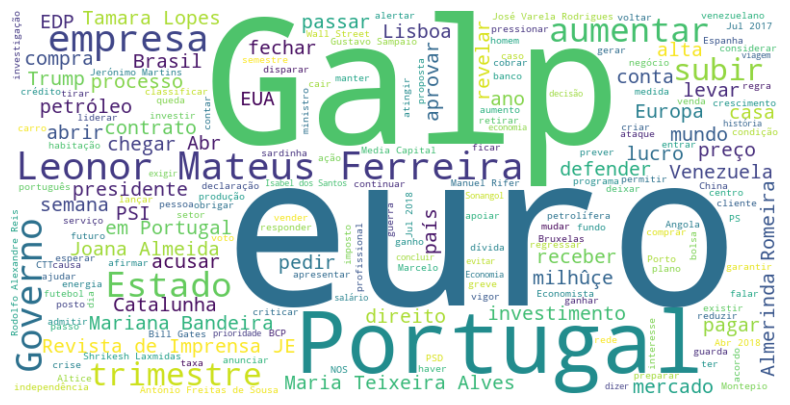

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


word_counts = {key: value["count"] for key, value in output.items()}

wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

- search for a specific word

In [15]:
search_topic = "EDP"

In [16]:
print(f"Number of news where both {query} and {search_topic} are mentioned: {output[search_topic]['count']}")

Number of news where both Galp and EDP are mentioned: 1444


In [17]:
# date

In [18]:
# sentiment

In [19]:
# source

In [20]:
# news